In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 


In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2022, 


In [6]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'
path2 = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2022.csv'

In [7]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-01-01,θεσσαλιας,αγιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.177143,14.644286,7.71,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,0.018327,0.018327,0.018327,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,0,0
1,22.69237,39.13639,2010-01-01,θεσσαλιας,αλμυρου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.237778,17.085556,11.39,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,0.210382,0.210382,0.210382,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,0,0
2,24.07379,39.32896,2010-01-01,θεσσαλιας,αλοννησου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.090000,17.810000,12.37,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,0.000000,0.000000,0.000000,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2010-01-01,θεσσαλιας,αργιθεας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,49.209201,49.209201,49.209201,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,0,0
4,22.88380,39.35198,2010-01-01,θεσσαλιας,βολου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.383333,NaN,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,0.000000,0.000000,0.000000,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,0,0


In [8]:
#Check months

dataset = dataset.query('month >= 7 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-07-01,θεσσαλιας,αγιας,1,7,26,2010,0.201299,0.979530,-0.500000,-0.866025,0.059241,-0.998244,661.8,10705.00,17.3,45.76610,0.532732,0.219176,-0.311430,-0.219176,0.539870,0.221632,-0.317112,-0.221632,0.039924,0.038129,0.059242,0.038129,23.167143,27.558571,18.775714,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,14.603265,32.963108,651.093528,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,16,0
1,22.69237,39.13639,2010-07-01,θεσσαλιας,αλμυρου,1,7,26,2010,0.201299,0.979530,-0.500000,-0.866025,0.059241,-0.998244,905.4,16004.00,20.6,45.23937,0.418745,0.086170,-0.339655,-0.086170,0.409503,0.078217,-0.336003,-0.078217,0.047497,0.048465,0.019969,0.048465,24.925556,33.147778,16.703333,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,13.128943,28.774132,628.943014,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,2,0
2,24.07379,39.32896,2010-07-01,θεσσαλιας,αλοννησου,1,7,26,2010,0.201299,0.979530,-0.500000,-0.866025,0.059241,-0.998244,129.6,3153.00,21.2,46.11198,0.398478,0.082908,-0.271522,-0.082908,0.407001,0.089733,-0.280608,-0.089733,0.016015,0.028079,0.024664,0.028079,24.220000,23.910000,24.530000,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,17.887174,60.010539,850.989312,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2010-07-01,θεσσαλιας,αργιθεας,1,7,26,2010,0.201299,0.979530,-0.500000,-0.866025,0.059241,-0.998244,372.9,3515.00,9.3,44.69433,0.500331,0.215688,-0.235004,-0.215688,0.494240,0.211831,-0.230308,-0.211831,0.039801,0.042501,0.040520,0.042501,21.010000,25.023333,16.996667,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,5.947388,23.696541,713.348882,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,20,0
4,22.88380,39.35198,2010-07-01,θεσσαλιας,βολου,1,7,26,2010,0.201299,0.979530,-0.500000,-0.866025,0.059241,-0.998244,385.6,138865.00,374.6,45.52194,0.400640,0.084082,-0.319725,-0.084082,0.374735,0.068303,-0.309515,-0.068303,0.052297,0.046849,0.015655,0.046849,28.070000,34.123333,22.016667,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,11.565395,27.264453,610.391199,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2431,22.55316,39.85211,2021-10-16,θεσσαλιας,τεμπων,16,10,41,2021,-0.101168,-0.994869,-0.866025,0.500000,-0.989040,0.147647,576.7,11.99,23.8,45.79122,0.496181,0.108527,-0.447561,-0.108527,0.494762,0.101525,-0.448295,-0.101525,0.062635,0.074820,0.037224,0.074820,21.208000,26.462000,15.954000,5.517741,0.477349,10.868515,4.723090,12.528034,2.774820,19.173602,5.501974,182.178094,252.813196,1038.541043,15

In [10]:
dataset2 = read_data(path2, exclude_years = years_to_remove)
dataset2.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-01-01,θεσσαλιας,αγιας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,661.8,10705.0,17.3,45.76610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.011429,12.470000,7.552857,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,0.000000,0.000000,0.000000,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,6,0,0
1,22.69237,39.13639,2022-01-01,θεσσαλιας,αλμυρου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,905.4,16004.0,20.6,45.23937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.749306,12.377500,7.121111,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,0.000138,0.000138,0.000138,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,5,0,0
2,24.07379,39.32896,2022-01-01,θεσσαλιας,αλοννησου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,129.6,3153.0,21.2,46.11198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.810000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,0.453699,0.453699,0.453699,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,1,0,0
3,21.43051,39.22138,2022-01-01,θεσσαλιας,αργιθεας,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,372.9,3515.0,9.3,44.69433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.273333,10.310000,6.236667,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,0.455287,0.455287,0.455287,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,12,0,0
4,22.88380,39.35198,2022-01-01,θεσσαλιας,βολου,1,1,52,2022,0.201299,0.97953,0.5,0.866025,-0.118273,0.992981,385.6,138865.0,374.6,45.52194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.363333,7.776667,8.950000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,0.000000,0.000000,0.000000,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,45,0,0


In [11]:
#Check months

dataset2 = dataset2.query('month >= 7 & month <= 10')
dataset2.reset_index(inplace=True, drop=True)

In [12]:
dataset2

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2022-07-01,θεσσαλιας,αγιας,1,7,26,2022,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,661.8,10705.00,17.3,45.76610,0.565795,0.165640,-0.512527,-0.165640,0.587336,0.191213,-0.522488,-0.191213,0.059030,0.046275,0.044986,0.046275,25.101429,30.710000,19.492857,5.780605,2.219699,9.428243,2.257183,10.448923,2.273378,21.082403,7.695856,165.021538,171.740579,892.770840,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,31,90,30,90.0,30,90,10,10,1,6,6,2,0,6,12,0
1,22.69237,39.13639,2022-07-01,θεσσαλιας,αλμυρου,1,7,26,2022,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,905.4,16004.00,20.6,45.23937,0.491892,0.138436,-0.447039,-0.138436,0.472337,0.123611,-0.432022,-0.123611,0.056833,0.054820,0.032884,0.054820,28.801111,36.158889,21.443333,8.616825,1.801932,11.624984,2.821047,13.074072,2.638302,22.638515,9.655879,37.525510,42.955282,691.599101,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,11,80,10,72.0,10,72,1,1,7,1,1,2,0,5,10,0
2,24.07379,39.32896,2022-07-01,θεσσαλιας,αλοννησου,1,7,26,2022,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,129.6,3153.00,21.2,46.11198,0.449294,0.076744,-0.402187,-0.076744,0.422329,0.057865,-0.369266,-0.057865,0.045487,0.030685,0.038494,0.030685,27.040000,31.050000,23.030000,10.958000,8.247143,12.676154,7.583333,12.528000,7.086364,19.002632,12.403333,1.218469,2.632859,858.279370,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,94,20,94.0,20,94,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2022-07-01,θεσσαλιας,αργιθεας,1,7,26,2022,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,372.9,3515.00,9.3,44.69433,0.574588,0.287520,-0.469132,-0.287520,0.535221,0.243618,-0.442667,-0.243618,0.036923,0.047173,0.022647,0.047173,24.103333,29.203333,19.003333,3.110000,-0.850636,6.849744,0.523152,6.386697,-1.146587,18.678205,6.829016,37.055255,37.594668,556.299563,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,97,10,99.0,10,99,1,1,7,1,1,2,0,12,24,0
4,22.88380,39.35198,2022-07-01,θεσσαλιας,βολου,1,7,26,2022,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,385.6,138865.00,374.6,45.52194,0.434905,0.081009,-0.400230,-0.081009,0.415239,0.071232,-0.384146,-0.071232,0.042178,0.043098,0.029763,0.043098,30.430000,39.490000,21.370000,10.279064,2.101397,13.378828,3.620000,14.613074,2.397455,24.653417,9.725712,23.625522,28.492052,676.696947,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,91,30,91.0,30,91,10,10,1,6,6,2,0,45,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,22.25731,39.56682,2022-09-01,θεσσαλιας,λαρισαιων,1,9,35,2022,0.201299,0.979530,-1.000000,-1.836970e-16,-0.845596,-0.533823,336.0,164381.00,483.9,45.39737,0.242602,-0.186117,-0.266601,0.186117,0.276567,-0.138791,-0.288544,0.138791,0.049921,0.061071,0.036903,0.061071,27.985000,35.770000,20.200000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.299333,9.236875,40.

In [13]:
dataset['lau1'].unique().shape

(25,)

In [14]:
dataset2['lau1'].unique().shape

(25,)

In [15]:
dataset = pd.concat([dataset, dataset2], axis=0)

In [16]:
dataset.reset_index(drop=True, inplace=True)

In [17]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2010-07-01,θεσσαλιας,αγιας,1,7,26,2010,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,661.8,10705.00,17.3,45.76610,0.532732,0.219176,-0.311430,-0.219176,0.539870,0.221632,-0.317112,-0.221632,0.039924,0.038129,0.059242,0.038129,23.167143,27.558571,18.775714,9.745684,4.044170,8.551413,3.117316,15.854022,4.895714,18.946151,6.782726,14.603265,32.963108,651.093528,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,8,16,0
1,22.69237,39.13639,2010-07-01,θεσσαλιας,αλμυρου,1,7,26,2010,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,905.4,16004.00,20.6,45.23937,0.418745,0.086170,-0.339655,-0.086170,0.409503,0.078217,-0.336003,-0.078217,0.047497,0.048465,0.019969,0.048465,24.925556,33.147778,16.703333,10.578306,4.632088,11.594181,4.298405,18.102979,6.260191,21.063313,8.144888,13.128943,28.774132,628.943014,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,2,0
2,24.07379,39.32896,2010-07-01,θεσσαλιας,αλοννησου,1,7,26,2010,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,129.6,3153.00,21.2,46.11198,0.398478,0.082908,-0.271522,-0.082908,0.407001,0.089733,-0.280608,-0.089733,0.016015,0.028079,0.024664,0.028079,24.220000,23.910000,24.530000,11.875455,10.167500,10.426667,8.035714,15.095333,9.928889,18.851600,10.540588,17.887174,60.010539,850.989312,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,2,0
3,21.43051,39.22138,2010-07-01,θεσσαλιας,αργιθεας,1,7,26,2010,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,372.9,3515.00,9.3,44.69433,0.500331,0.215688,-0.235004,-0.215688,0.494240,0.211831,-0.230308,-0.211831,0.039801,0.042501,0.040520,0.042501,21.010000,25.023333,16.996667,0.274889,0.318889,3.929167,-0.943095,11.973413,2.839991,16.749405,6.439643,5.947388,23.696541,713.348882,17128.150567,2537.700531,21,116.335477,1163.031269,147.596517,0.0,1.107140,11,93,10,95.0,10,95,1,1,7,1,1,2,0,10,20,0
4,22.88380,39.35198,2010-07-01,θεσσαλιας,βολου,1,7,26,2010,0.201299,0.979530,-0.500000,-8.660254e-01,0.059241,-0.998244,385.6,138865.00,374.6,45.52194,0.400640,0.084082,-0.319725,-0.084082,0.374735,0.068303,-0.309515,-0.068303,0.052297,0.046849,0.015655,0.046849,28.070000,34.123333,22.016667,14.044643,4.790926,13.656768,4.280179,19.413810,6.542459,24.387230,8.781836,11.565395,27.264453,610.391199,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,13,26,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2638,22.25731,39.56682,2022-09-01,θεσσαλιας,λαρισαιων,1,9,35,2022,0.201299,0.979530,-1.000000,-1.836970e-16,-0.845596,-0.533823,336.0,164381.00,483.9,45.39737,0.242602,-0.186117,-0.266601,0.186117,0.276567,-0.138791,-0.288544,0.138791,0.049921,0.061071,0.036903,0.061071,27.985000,35.770000,20.200000,10.551929,-1.222353,15.475000,0.971818,17.306667,0.820833,28.299333,9.236875,40.3

In [18]:
print(f'Number of LAU1 Units in {NUTS2}: {len(dataset.lau1.unique())}')

Number of LAU1 Units in Thessaly: 26


In [19]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,194,9,203,7.68%
1,2011,177,30,207,7.83%
2,2012,200,0,200,7.57%
3,2013,200,0,200,7.57%
4,2014,200,0,200,7.57%
5,2015,200,0,200,7.57%
6,2016,200,0,200,7.57%
7,2017,200,0,200,7.57%
8,2018,195,7,202,7.64%
9,2019,170,53,223,8.44%


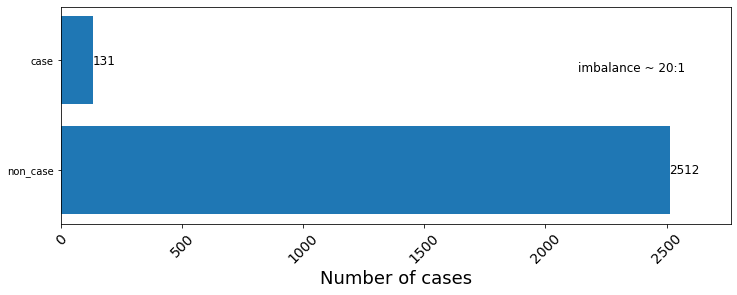

In [20]:
plot_imbalance(dataset)

In [21]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [22]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:8 || ##
Year: 2011 || w0:1, w1:9 || ##
Year: 2012 || w0:1, w1:7 || ##
Year: 2013 || w0:1, w1:7 || ##
Year: 2014 || w0:1, w1:7 || ##
Year: 2015 || w0:1, w1:7 || ##
Year: 2016 || w0:1, w1:7 || ##
Year: 2017 || w0:1, w1:7 || ##
Year: 2018 || w0:1, w1:7 || ##
Year: 2019 || w0:1, w1:12 || ##
Year: 2020 || w0:1, w1:8 || ##
Year: 2021 || w0:1, w1:7 || ##
Year: 2022 || w0:1, w1:8 || ##


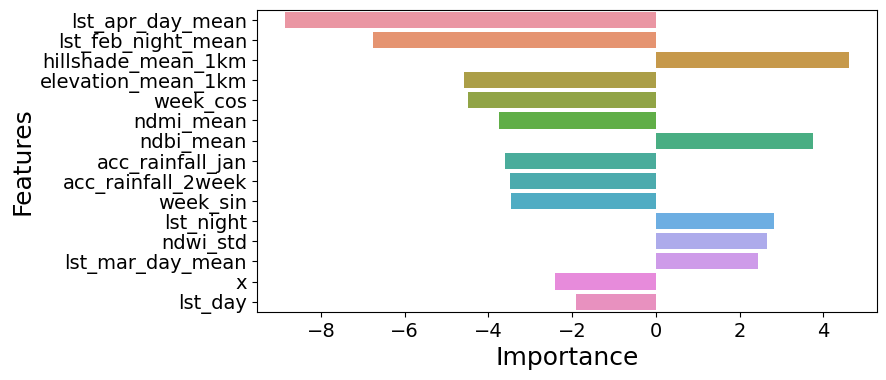

In [23]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

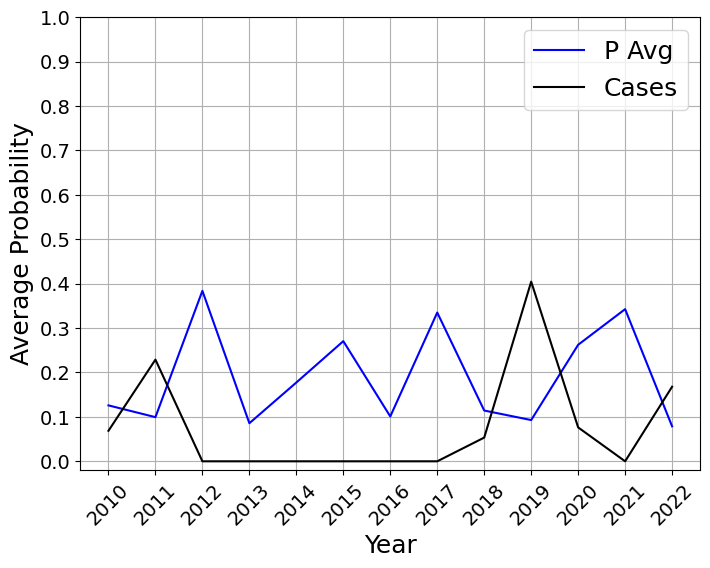

In [24]:
plot_trend_curve(results_test, list(dsc['case']))

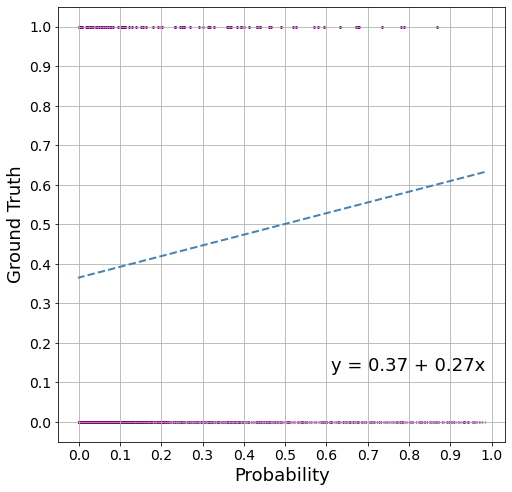

In [25]:
plot_probability_curve(results_test)

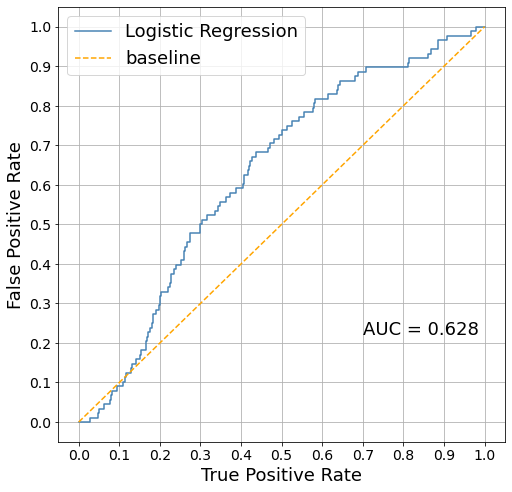

In [26]:
plot_roc_curve(results_test)

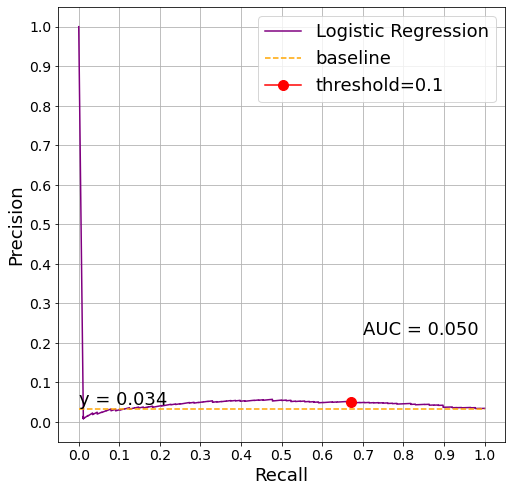

In [27]:
plot_pr_curve(results_test, plot_fbeta=True)

In [31]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 4, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 43.03%
Weighted Average: 43.51%

Random Average: 19.19%
Random Weighted Average: 20.99%


In [32]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/07/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/07/2010,1,0,0.17,1,0.00 %,0.0000,17.00 %,0.1700
2,01/08/2010,1,0,0.20,1,0.00 %,0.0000,20.00 %,0.2000
3,16/08/2010,2,1,0.28,2,50.00 %,0.5000,14.00 %,0.1400
4,01/09/2010,2,1,0.33,2,50.00 %,0.5000,16.50 %,0.1650
...,...,...,...,...,...,...,...,...,...
99,16/08/2022,4,1,0.61,4,25.00 %,0.2500,15.25 %,0.1525
100,01/09/2022,2,0,0.26,2,0.00 %,0.0000,13.00 %,0.1300
101,16/09/2022,4,1,0.69,4,25.00 %,0.2500,17.25 %,0.1725
102,01/10/2022,3,1,0.48,3,33.33 %,0.3333,16.00 %,0.1600


In [33]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,6,2,0.98,6,33.33 %,0.3333,16.33 %,0.1633
1,2011,23,8,3.76,16,50.00 %,0.5000,23.50 %,0.2350
2,2012,0,0,0.00,0,nan %,NaN,nan %,NaN
3,2013,0,0,0.00,0,nan %,NaN,nan %,NaN
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,5,4,0.95,5,80.00 %,0.8000,19.00 %,0.1900
9,2019,30,10,4.67,19,52.63 %,0.5263,24.58 %,0.2458


In [31]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [32]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,6.0000,0.3400,0.8402,0.0882,1.0000,0.6220,0.1827
1,2011,23.0000,0.3050,0.7698,0.2951,0.7826,0.7133,0.2896
2,2012,0.0000,0.7250,0.2750,0.0000,0.0000,0.0000,0.7435
3,2013,0.0000,0.2450,0.7550,0.0000,0.0000,0.0000,0.1059
4,2014,0.0000,0.5100,0.4900,0.0000,0.0000,0.0000,0.2443
5,2015,0.0000,0.5600,0.4400,0.0000,0.0000,0.0000,0.4875
6,2016,0.0000,0.3100,0.6900,0.0000,0.0000,0.0000,0.1249
7,2017,0.0000,0.7050,0.2950,0.0000,0.0000,0.0000,0.5712
8,2018,5.0000,0.2500,0.6795,0.0600,0.6000,0.3923,0.2179
9,2019,30.0000,0.2650,0.7363,0.3774,0.6667,0.6379,0.3504


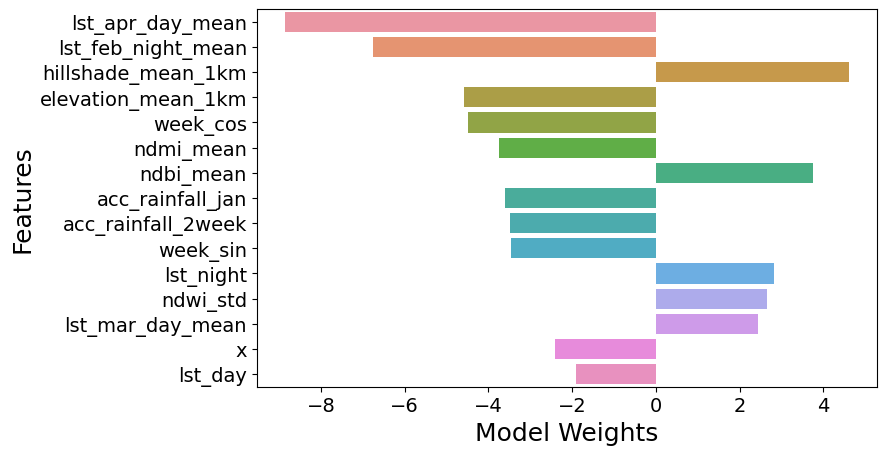

In [33]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))

In [34]:
results_test[results_test['year'] == 2022].head(30)

,x,y,municipality,day,month,year,case,probability
200,21.72537,39.29671,λιμνης πλαστηρα,1,8,2022,0,0.676921
257,21.72537,39.29671,λιμνης πλαστηρα,16,8,2022,0,0.621994
264,21.79756,39.63506,τρικκαιων,16,8,2022,0,0.611659
269,21.79756,39.63506,τρικκαιων,1,8,2022,0,0.608457
317,21.72537,39.29671,λιμνης πλαστηρα,16,9,2022,0,0.545951
408,21.72537,39.29671,λιμνης πλαστηρα,16,7,2022,0,0.456809
426,21.79756,39.63506,τρικκαιων,16,9,2022,0,0.441136
453,21.88992,39.23076,καρδιτσας,16,8,2022,0,0.423081
472,22.47968,39.49921,κιλελερ,1,8,2022,0,0.403407
476,21.79756,39.63506,τρικκαιων,16,7,2022,0,0.398017
